## Prepare data

In [1]:
import os
import sys
sys.path.append("../..")

import json
from collections import Counter

import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.special import softmax

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

from services.udpipe_model import UDPipeModel
from services.utils_data import read_and_transform_data
from services.config import PATH_TO_SOURCE_UDPIPE

/home/victor_muryn/ConEfuV2/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TOP_K = 5
TEMPERATURE = 0.2
CUT_OFF_PROBABILITY = 0.7
CUT_OFF_SIMILARITY = 0.7

BATCH_SIZE = 64

MODEL_NAME_OR_PATH = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
UDPIPE_MODEL = os.path.join("../../", PATH_TO_SOURCE_UDPIPE)

desired_lemma = "коса"

In [3]:
embedder = SentenceTransformer(MODEL_NAME_OR_PATH, device="cuda:1")

In [4]:
with open('../raw_sentences/unique_lemma_sentences.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

len(data)

1362

In [5]:
for idx, item in enumerate(data, start=1):
    print(f"{idx}: {item['lemma']}")

1: випасти
2: ніколи
3: вистава
4: початок
5: повставати
6: піхва
7: око
8: крапка
9: звільнити
10: зараз
11: заходитися
12: година
13: попадатися
14: позад
15: губа
16: дихання
17: мати
18: околиця
19: зачепити
20: пора
21: ніяк
22: подавати
23: перепросити
24: гадати
25: двір
26: біль
27: ордер
28: позаду
29: немов
30: кілька
31: місто
32: покидати
33: верхогляд
34: поправити
35: крик
36: пойняти
37: запастися
38: гаразд
39: косити
40: лава
41: задерти
42: відповідний
43: орган
44: значити
45: виводити
46: зволікати
47: затока
48: голосити
49: кубанка
50: поза
51: постать
52: заряд
53: біда
54: дякувати
55: пістоль
56: закрутити
57: поточитися
58: куля
59: котитися
60: зав'язати
61: полька
62: вино
63: гармонія
64: попереду
65: ковток
66: вигадати
67: негаразд
68: закурити
69: звір
70: поміж
71: кома
72: зринати
73: наголос
74: жужелиця
75: весь
76: вибігати
77: западати
78: доля
79: буцім
80: нота
81: відділ
82: загін
83: копати
84: заскалити
85: китайка
86: карабін
87: курити
88: п

In [6]:
lemma_idx = next(i for i, item in enumerate(data) if item["lemma"] == desired_lemma)
lemma_idx

234

In [7]:
data[lemma_idx]["lemma"], len(data[lemma_idx]["sentences"])

('коса', 7079)

In [8]:
sum_14 = read_and_transform_data("../../datasets_pre_defined/sum_14_final.jsonlines", homonym=True)
sum_14.head()

,lemma,gloss,examples
0,абака,"[Чотирикутна плита, якою завершується верхня ч...",[Абака – плоска плита у верхній частині капіте...
1,абака,[Пальмоподібна багаторічна тропічна рослина ро...,[Кращий у світі канат – манільський – робиться...
2,аверс,"[Лицевий бік монети, медалі, медальйона ]",[На аверсі монети на фоні півкуль Землі зображ...
3,аверс,"[Прямий напрямок руху; використання механізму,...","[– Ви знаєте, що практично з часу введення в е..."
4,автостоп,"[Пристрій, що забезпечує автоматичну зупинку п...",[У систему автостопа входять елементи (трансмі...


In [9]:
sum_14["lemma"].nunique()

1464

In [9]:
meanings = sum_14[sum_14["lemma"] == desired_lemma]

print(f"Lemma: {meanings.iloc[0].lemma}")
for meaning in meanings.itertuples():
    print(f"Gloss: {meaning.gloss}")
    
    for sentence in meaning.examples:
        print(f" - {sentence}")
    print()

Lemma: коса
Gloss: ['Довге волосся', 'Заплетене волосся']
 - Хто се, хто се по тім боці Рве на собі коси?..
 - Густі, золото-жовті коси буйними хвилями спадали на її груди і плечі
 - Дівча біжить в тяжкім одчаї, Коса їй плечі устеляє
 - Побачив   дівчину – випростану, з гордо зведеною головою.., її довгі коси були розпущені поверх білосніжного вбрання
 - По один бік глибокого темного шляху білокорі берези в розпущених зелених косах
 - Якраз під старою вишнею .. стояла дівчина, хороша, як зоря ясна; руса коса нижче пояса
 - Очі в неї були великі, дві чорні коси, перекинуті наперед, обрамляли лице
 - Це вперше він побачив її без шапки, побачив гладенько зачесане на проділ волосся, заплетене в тугу золотисту косу, що спадала на груди через плече

Gloss: ["Сільськогосподарське знаряддя для косіння трави, зернових , що має форму вузького зігнутого леза, прикріпленого до кісся дерев'яного держака"]
 - Свідок слави, дідівщини З вітром розмовляє, А внук косу несе в росу, За ними співає
 -  Кос

In [10]:
len(meanings)

5

In [17]:
meanings_embeddings = []

for i in meanings.itertuples():
    glosses = i.gloss if isinstance(i.gloss, (list, tuple)) else [i.gloss]
    # encode returns ndarray shape (n_glosses, dim)
    gloss_embs = embedder.encode(
        glosses,
        batch_size=min(BATCH_SIZE, max(1, len(glosses))),
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    # average embeddings if multiple gloss strings per meaning (same behaviour as before)
    mean_emb = np.mean(gloss_embs, axis=0)
    meanings_embeddings.append(mean_emb)

meanings_embeddings = np.vstack(meanings_embeddings)
meanings_embeddings.shape

(5, 768)

In [16]:
train_set_embeddings = []

train_set_embeddings = embedder.encode(
    data[lemma_idx]["sentences"],
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=["cuda:0", "cuda:1"]
)

train_set_embeddings.shape

Chunks: 100%|██████████| 20/20 [00:05<00:00,  3.57it/s]


(7079, 768)

# Plot

## Without classes

In [18]:
# find top 5 closest meanings for each meaning_embedding 
train_set_embeddings = np.array(train_set_embeddings)

# plot PCA of meanings_embeddings and train_set_embeddings
all_embeddings = np.vstack([meanings_embeddings, train_set_embeddings])

n_meanings = meanings_embeddings.shape[0]
n_total = all_embeddings.shape[0]

In [19]:
pca = PCA(n_components=2, random_state=42)
all_embeddings_2d = pca.fit_transform(all_embeddings)

meanings_2d = all_embeddings_2d[:n_meanings]
train_2d = all_embeddings_2d[n_meanings:]

/tmp/ipykernel_202919/4121880546.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/tmp/ipykernel_202919/4121880546.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


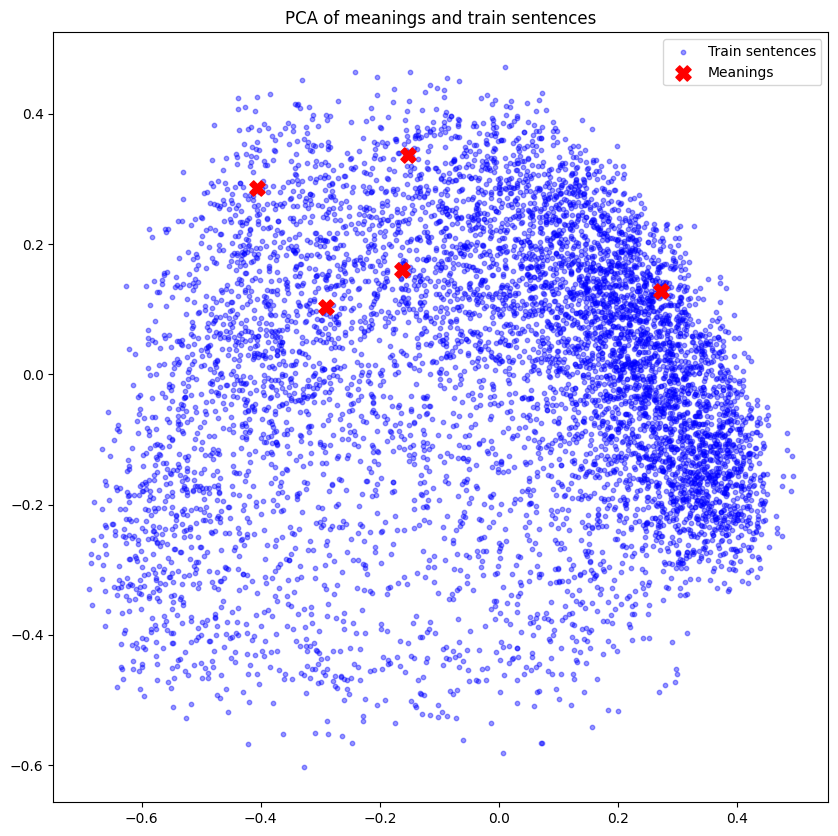

In [20]:
# plotting
plt.figure(figsize=(10, 10))

plt.scatter(
    train_2d[:, 0],
    train_2d[:, 1],
    c="blue",
    alpha=0.4,
    s=10,
    cmap='tab10',
    label="Train sentences"
)

plt.scatter(
    meanings_2d[:, 0],
    meanings_2d[:, 1],
    c="red",
    s=120,
    marker="X",
    cmap='tab10',
    label="Meanings"
)

plt.legend()
plt.title("PCA of meanings and train sentences")
plt.show()

In [21]:
# Display the top 5 closest sentences for each meaning
similarity_matrix = cosine_similarity(meanings_embeddings, train_set_embeddings)
prob_matrix = softmax(similarity_matrix / TEMPERATURE, axis=0)
top_k_indices = np.argsort(-prob_matrix, axis=1)[:, :TOP_K]

for meaning_idx, indices in enumerate(top_k_indices):
    print(f"Meaning {meaning_idx + 1}: {meanings.iloc[meaning_idx].gloss}")

    for rank, sentence_idx in enumerate(indices):
        sentence = data[lemma_idx]["sentences"][sentence_idx]
        similarity_score = similarity_matrix[meaning_idx, sentence_idx]
        prob_score = prob_matrix[meaning_idx, sentence_idx]
        print(f"  {rank + 1}. (sim: {similarity_score:.4f}, prob: {prob_score:.4f}) {sentence}")

    print()

Meaning 1: ['Довге волосся', 'Заплетене волосся']
  1. (sim: 0.7774, prob: 0.7855) Коси на довге волосся - це красива і жіночна ідея.
  2. (sim: 0.8378, prob: 0.7808) Розкішне волосся кольору міді переплетене в коси,вільні пасма завиті в буклі по останній моді.
  3. (sim: 0.8232, prob: 0.7726) ЇЇ довге світле волосся, найчастіше заплетене у дві коси.
  4. (sim: 0.7735, prob: 0.7711) Своє пишне волосся дівчина ретельно розчесала на проділ і заплела в дві товсті коси.
  5. (sim: 0.7453, prob: 0.7687) Її світле довге волосся заплетене в тугі коси.

Meaning 2: ["Сільськогосподарське знаряддя для косіння трави, зернових , що має форму вузького зігнутого леза, прикріпленого до кісся дерев'яного держака"]
  1. (sim: 0.8314, prob: 0.7056) КОСА — ручне знаряддя для косіння трави та зернових культур.
  2. (sim: 0.7267, prob: 0.6995) Землю селяни обробляли примітивними знаряддями праці (рало і борона дерев'яні, серп, коса, ціп), сіяли вручну.
  3. (sim: 0.7249, prob: 0.6864) Окрім сучасної сільсь

## with classes

In [22]:
colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
]

cmap = ListedColormap(colors[:n_meanings])

In [23]:
# --------
# 1) assign train points to closest meaning (by cosine)
# --------
# For each train sample, pick meaning index with max similarity
assigned_prob = np.argmax(prob_matrix, axis=0)  # shape (n_train,)
max_probs = np.max(prob_matrix, axis=0)
assigned_prob[max_probs < CUT_OFF_PROBABILITY] = -1  # assign -1 for low confidence

# similarity-based assignment
assigned_sim = np.argmax(similarity_matrix, axis=0)  # (n_train,)
max_sims = np.max(similarity_matrix, axis=0)
assigned_sim[max_sims < CUT_OFF_SIMILARITY] = -1

In [24]:
# --------
# 2) PCA of combined embeddings
# --------
pca = PCA(n_components=2, random_state=42)

all_embeddings_2d = pca.fit_transform(all_embeddings)
meanings_2d = all_embeddings_2d[:n_meanings]
train_2d = all_embeddings_2d[n_meanings:]

In [25]:
def plot_assignment(ax, title, assignment, train_2d, meanings_2d):
    assigned_mask = assignment >= 0
    unassigned_mask = assignment == -1

    ax.scatter(
        train_2d[assigned_mask, 0],
        train_2d[assigned_mask, 1],
        c=cmap(assignment[assigned_mask]),
        # cmap=cmap,
        s=20,
        alpha=0.8,
        linewidths=0,
    )

    ax.scatter(
        train_2d[unassigned_mask, 0],
        train_2d[unassigned_mask, 1],
        c="lightgray",
        s=20,
        alpha=0.4,
        linewidths=0,
    )

    ax.scatter(
        meanings_2d[:, 0],
        meanings_2d[:, 1],
        c=cmap(np.arange(n_meanings)),
        # cmap=cmap,
        s=260,
        marker="X",
        edgecolors="black",
        linewidths=1.0,
    )

    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

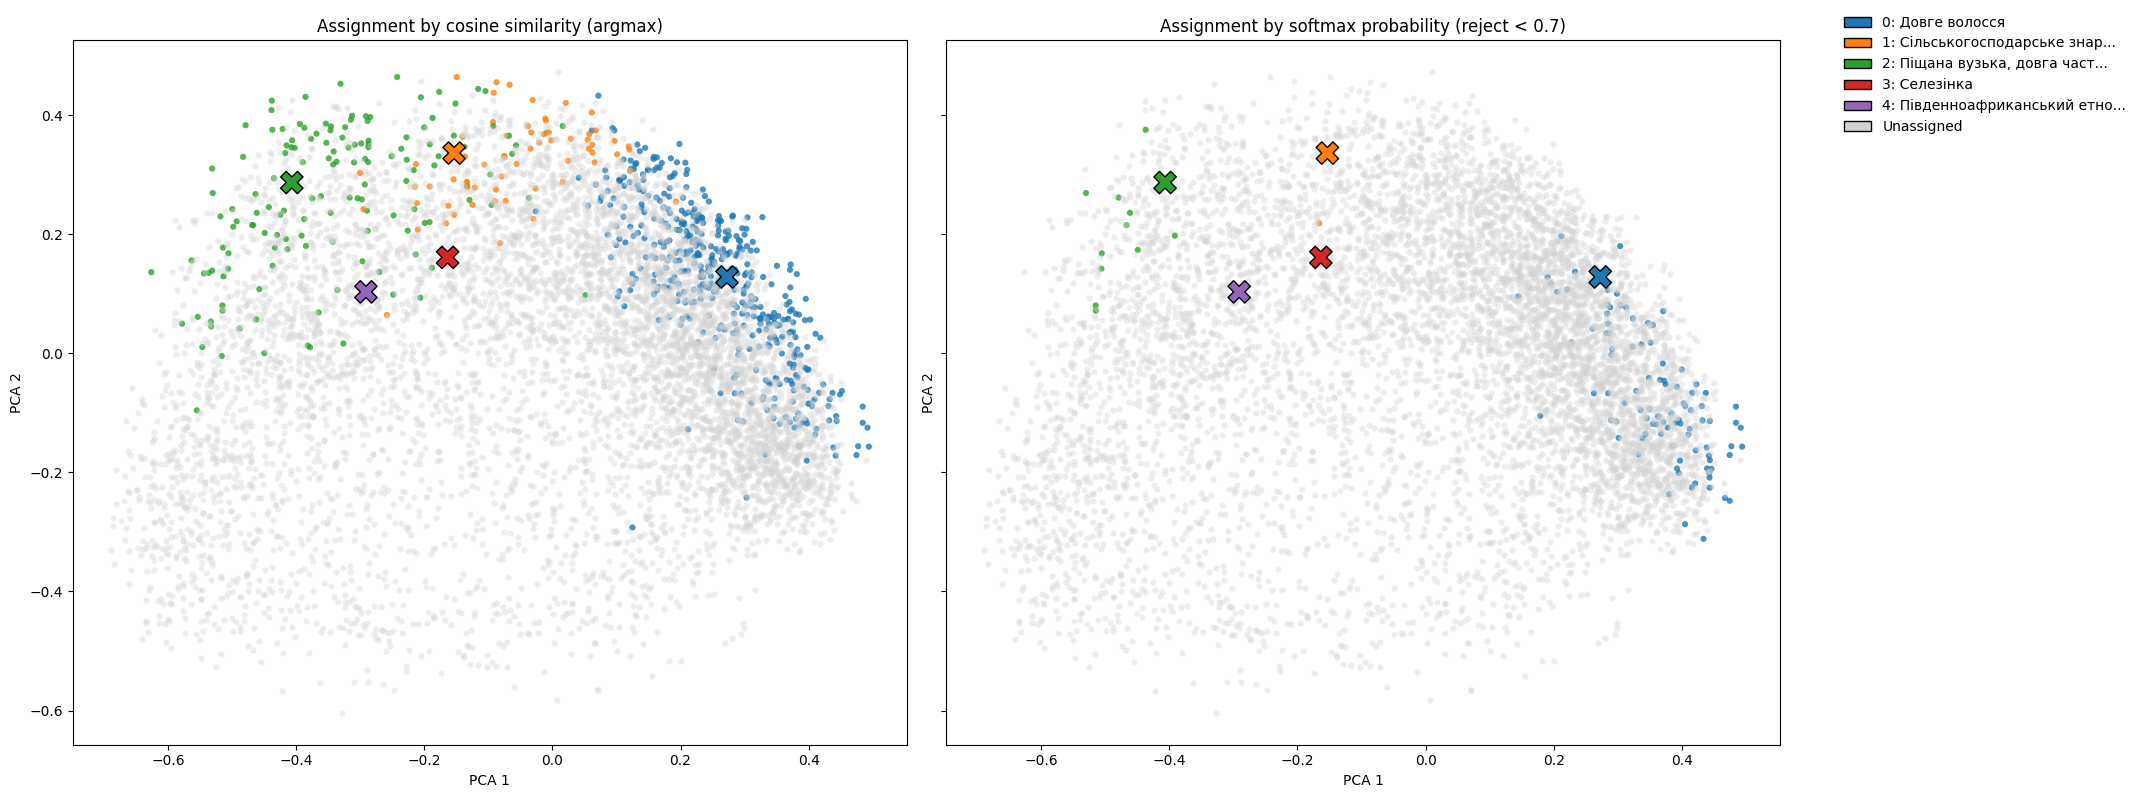

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

plot_assignment(
    axes[0],
    "Assignment by cosine similarity (argmax)",
    assigned_sim,
    train_2d,
    meanings_2d,
)

plot_assignment(
    axes[1],
    f"Assignment by softmax probability (reject < {CUT_OFF_PROBABILITY})",
    assigned_prob,
    train_2d,
    meanings_2d,
)

legend_handles = []

for i in range(n_meanings):
    name = f"Meaning {i}"
    short = meanings.iloc[i].gloss[0]
    if short:
        name = f"{i}: {short[:25]}{'...' if len(short) > 25 else ''}"

    legend_handles.append(
        Patch(facecolor=cmap(i), edgecolor="black", label=name)
    )

legend_handles.append(
    Patch(facecolor="lightgray", edgecolor="black", label="Unassigned")
)

fig.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()


In [27]:
# --------
# 4) Print top-k sentences per meaning (safe fallback if `meanings` contains human-readable glosses)
# --------
for meaning_idx in range(n_meanings):
    # indices of top-k train sentences (highest similarity to this meaning)
    top_indices = np.lexsort((
        -similarity_matrix[meaning_idx],   # secondary key
        -prob_matrix[meaning_idx],  # primary key
    ))

    # delete those, which have prob < CUT_OFF_PROBABILITY
    top_indices = [idx for idx in top_indices if prob_matrix[meaning_idx, idx] >= 0.6 and similarity_matrix[meaning_idx, idx] >= 0.4]

    # header
    header = f"Meaning {meaning_idx}"
    glosses = " | ".join(meanings.iloc[meaning_idx].gloss)
    if glosses:
        header += f": {glosses}"
            
    print(header)
    
    for rank, sent_idx in enumerate(top_indices, start=1):
        sent = data[lemma_idx]["sentences"][sent_idx]
        sim = similarity_matrix[meaning_idx, sent_idx]
        prob = prob_matrix[meaning_idx, sent_idx]

        print(f"  {rank}. (idx={sent_idx}, sim={sim:.4f}, prob={prob:.4f}) {sent}")
    print()

Meaning 0: Довге волосся | Заплетене волосся
  1. (idx=4928, sim=0.7774, prob=0.7855) Коси на довге волосся - це красива і жіночна ідея.
  2. (idx=5598, sim=0.8378, prob=0.7808) Розкішне волосся кольору міді переплетене в коси,вільні пасма завиті в буклі по останній моді.
  3. (idx=1054, sim=0.8232, prob=0.7726) ЇЇ довге світле волосся, найчастіше заплетене у дві коси.
  4. (idx=3967, sim=0.7735, prob=0.7711) Своє пишне волосся дівчина ретельно розчесала на проділ і заплела в дві товсті коси.
  5. (idx=3284, sim=0.7453, prob=0.7687) Її світле довге волосся заплетене в тугі коси.
  6. (idx=1046, sim=0.8398, prob=0.7659) Об'ємна коса - трендова зачіска, яка виглядає ошатно і одночасно акуратно.
  7. (idx=6595, sim=0.6958, prob=0.7644) Красуня обстригла свої довгі коси та перефарбувалася в білявку.
  8. (idx=4503, sim=0.7448, prob=0.7641) Окрім одягу, дівчата відрізняються зачісками, хоч усі мають довге волосся, заплетене в коси.
  9. (idx=3110, sim=0.7549, prob=0.7639) "Я люблю мої довгі

# K-Means

In [24]:
# make k-means clustering on train_set_embeddings with k = number of meanings
k = len(meanings)
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(train_set_embeddings)
labels = kmeans.labels_
labels.shape

(42650,)

In [25]:
# count how many sentences in each cluster
label_counts = Counter(labels)
label_counts

Counter({1: 22649, 0: 20001})

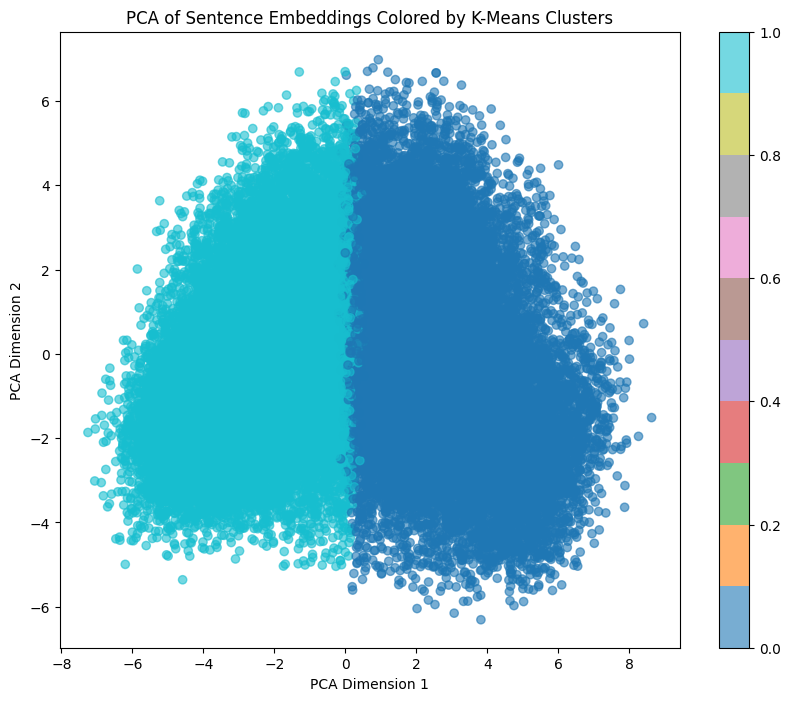

In [26]:
# plot T-SNE of train_set_embeddings colored by cluster labels
pca = PCA(n_components=2, random_state=42)
train_set_embeddings_2d = pca.fit_transform(train_set_embeddings)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    train_set_embeddings_2d[:, 0],
    train_set_embeddings_2d[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.6
)
plt.colorbar(scatter)
plt.title("PCA of Sentence Embeddings Colored by K-Means Clusters")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.show()

In [27]:
# print top 5 sentences from each cluster (that are closest to the cluster center)
for cluster_id in range(k):
    cluster_center = kmeans.cluster_centers_[cluster_id]
    cluster_sentences_indices = np.where(labels == cluster_id)[0]
    cluster_sentences_embeddings = train_set_embeddings[cluster_sentences_indices]
    similarities_to_center = cosine_similarity(cluster_sentences_embeddings, cluster_center.reshape(1, -1)).flatten()
    top_5_indices = np.argsort(-similarities_to_center)[:5]
    
    print(f"Cluster {cluster_id + 1}:")
    for idx in top_5_indices:
        sentence_idx = cluster_sentences_indices[idx]
        sentence = data[lemma_idx]["sentences"][sentence_idx]
        similarity_score = similarities_to_center[idx]
        print(f"  - {sentence} (Similarity to center: {similarity_score:.4f})")

    print()

Cluster 1:
  - Колись це був потужний замок, але зараз мало що від нього залишилося. (Similarity to center: 0.9368)
  - На той час замок був сильно пошкоджений під час бойових дій. (Similarity to center: 0.9342)
  - Замок свого часу зайняли австрійці – вони зайшли і вийшли, нічого не взявши. (Similarity to center: 0.9341)
  - Колись це був міцний замок, нині від нього лишилися вбогі руїни. (Similarity to center: 0.9339)
  - Замок був закинутий, перетворився на руїни і заріз плющем. (Similarity to center: 0.9338)

Cluster 2:
  - — Відтоді навіть потрапити туди не можу, там уже інший замок. (Similarity to center: 0.9382)
  - Якщо дегустація пройшла без важких наслідків – підніміться у місцевий замок. (Similarity to center: 0.9375)
  - В замку зламана відмичка, в квартирі відкриті дверцята шаф і тумбочок. (Similarity to center: 0.9373)
  - «Ми прийшли – замок висів, охорона, і тут були представники обласної ради. (Similarity to center: 0.9367)
  - — У них є родовий замок, в якому ми й поб

# Get embeddings of target words only

In [ ]:
udpipe_model = UDPipeModel(UDPIPE_MODEL)

## extract embeddings

In [ ]:
def _find_target_word_in_sentence(udpipe_model: UDPipeModel, input_text: str, target_word: str):
    tokenized = udpipe_model.tokenize(input_text)
    
    for tok_sent in tokenized:
        udpipe_model.tag(tok_sent)
        
        for word_index, w in enumerate(tok_sent.words[1:]):  # under 0 index is root
            if w.lemma.lower() == target_word.lower():
                return tok_sent.words[word_index+1].form

    return None

def normalize_word(word: str) -> str:
        # .replace("«", "").replace("»", "") \
        # .replace('"', '') \
    return word \
        .replace("(", "").replace(")", "") \
        .replace(",", "").replace(".", "") \
        .strip()

def _find_target_word_in_tokenized_text(tokenizer, tokenized_input_text, word: str):
    unique_w_ids = list(set(tokenized_input_text.word_ids()))
    unique_w_ids.remove(None)
    tokens = ["" for _ in range(len(unique_w_ids))]

    word_indexes = []
    prev_word_id = None

    target_words_with_indexes = []

    zipped = zip(tokenized_input_text["input_ids"][0], tokenized_input_text.word_ids())
    for index, (input_id, word_id) in enumerate(zipped):
        token = tokenizer.decode([input_id]).strip()

        if prev_word_id == word_id:
            word_indexes.append(index)

        else:
            word_indexes = []
            word_indexes.append(index)

        prev_word_id = word_id

        if word_id is None:
            continue

        if token.startswith("##"):
            token = token.replace("##", "")

        tokens[word_id] += token
        tokens_word = tokens[word_id].replace("▁", "").lower()
        tokens_word = normalize_word(tokens_word)
        
        if tokens_word == word.lower():
            target_words_with_indexes.append((word, word_indexes.copy()))

    return target_words_with_indexes

def get_target_word_embedding_idx(udpipe_model, tokenizer, sentence: str, lemma: str):
    word_in_sentence = _find_target_word_in_sentence(udpipe_model, sentence, lemma)

    if not word_in_sentence:
        return None, None
    
    inputs = tokenizer(sentence, return_tensors="pt")
    word_positions = _find_target_word_in_tokenized_text(tokenizer, inputs, word_in_sentence)

    if not word_positions:
        return word_in_sentence, None

    return word_positions[0]

In [ ]:
batch_size = 256
train_set_embeddings = []

# Compute embeddings in batches
for i in tqdm(range(0, len(data[lemma_idx]["sentences"]), batch_size)):
    batch_sentences = data[lemma_idx]["sentences"][i:i+batch_size]
    inputs = tokenizer(
        batch_sentences,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to("cuda")

    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state
    
    for j, sentence in enumerate(batch_sentences):
        word, positions = get_target_word_embedding_idx(udpipe_model, tokenizer, sentence, data[lemma_idx]["lemma"])
        if positions is None:
            # fallback: use mean of all tokens
            embedding = embeddings[j].mean(dim=0)
        else:
            # average embeddings of target word tokens
            token_embeddings = embeddings[j][positions]
            embedding = token_embeddings.mean(dim=0)
        
        batch_embedding = embedding.detach().cpu().numpy()
        train_set_embeddings.append(batch_embedding)

100%|██████████| 28/28 [00:14<00:00,  1.87it/s]


## plot without classes

In [ ]:
# find top 5 closest meanings for each meaning_embedding 
train_set_embeddings = np.array(train_set_embeddings)

# plot PCA of meanings_embeddings and train_set_embeddings
all_embeddings = np.vstack([meanings_embeddings, train_set_embeddings])

n_meanings = meanings_embeddings.shape[0]
n_total = all_embeddings.shape[0]

In [ ]:
pca = PCA(n_components=2, random_state=42)

all_embeddings_2d = pca.fit_transform(all_embeddings)

meanings_2d = all_embeddings_2d[:n_meanings]
train_2d = all_embeddings_2d[n_meanings:]

/tmp/ipykernel_1067755/4121880546.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/tmp/ipykernel_1067755/4121880546.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


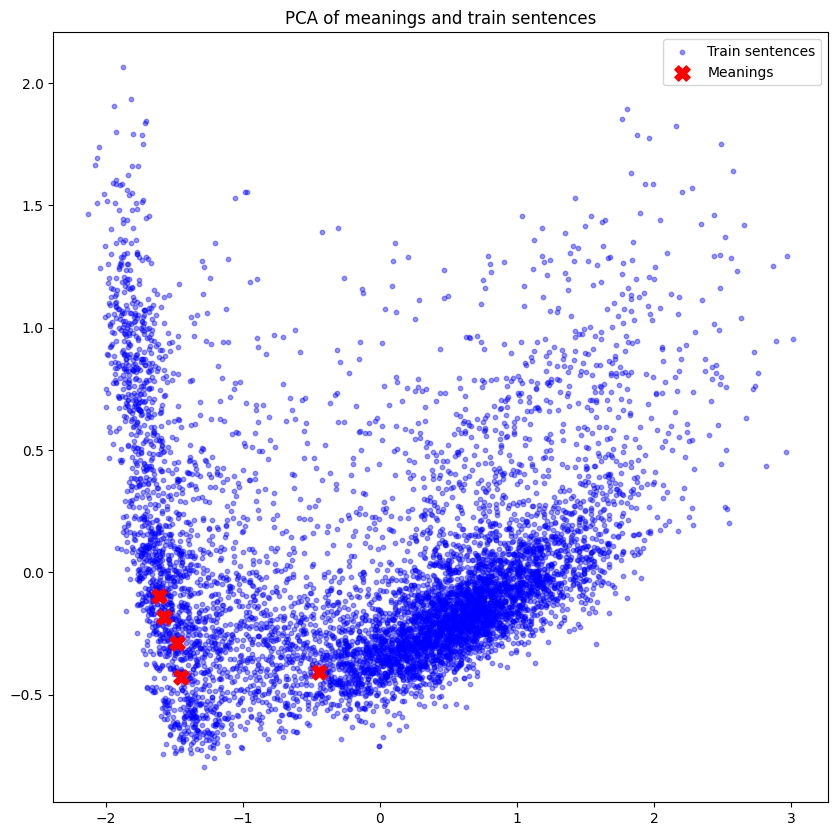

In [ ]:
# plotting
plt.figure(figsize=(10, 10))

plt.scatter(
    train_2d[:, 0],
    train_2d[:, 1],
    c="blue",
    alpha=0.4,
    s=10,
    cmap='tab10',
    label="Train sentences"
)

plt.scatter(
    meanings_2d[:, 0],
    meanings_2d[:, 1],
    c="red",
    s=120,
    marker="X",
    cmap='tab10',
    label="Meanings"
)

plt.legend()
plt.title("PCA of meanings and train sentences")
plt.show()

In [ ]:
# Display the top 5 closest sentences for each meaning
similarity_matrix = cosine_similarity(meanings_embeddings, train_set_embeddings)
prob_matrix = softmax(similarity_matrix / TEMPERATURE, axis=0)
top_k_indices = np.argsort(-prob_matrix, axis=1)[:, :TOP_K]

for meaning_idx, indices in enumerate(top_k_indices):
    print(f"Meaning {meaning_idx + 1}: {meanings[meaning_idx]['gloss'][0]}")
    print(f"Meaning example: {meanings[meaning_idx]['examples'][0]['ex_text'] if meanings[meaning_idx]['examples'] else 'N/A'}")

    for rank, sentence_idx in enumerate(indices):
        sentence = data[lemma_idx]["sentences"][sentence_idx]
        similarity_score = similarity_matrix[meaning_idx, sentence_idx]
        prob_score = prob_matrix[meaning_idx, sentence_idx]
        print(f"  {rank + 1}. (sim: {similarity_score:.4f}, prob: {prob_score:.4f}) {sentence}")

    print()

KeyError: 0

## plot with classes

In [ ]:
# --------
# 1) assign train points to closest meaning (by cosine)
# --------
# For each train sample, pick meaning index with max similarity
assigned_prob = np.argmax(prob_matrix, axis=0)  # shape (n_train,)
max_probs = np.max(prob_matrix, axis=0)
assigned_prob[max_probs < 0.85] = -1  # assign -1 for low confidence

# similarity-based assignment
assigned_sim = np.argmax(similarity_matrix, axis=0)  # (n_train,)
max_sims = np.max(similarity_matrix, axis=0)
assigned_sim[max_sims < 0.7] = -1

combined_classes = assigned_sim.copy()
combined_classes[assigned_prob != assigned_sim] = -1

In [ ]:
# --------
# 2) PCA of combined embeddings
# --------
pca = PCA(n_components=2, random_state=42)

all_embeddings_2d = pca.fit_transform(all_embeddings)
meanings_2d = all_embeddings_2d[:n_meanings]
train_2d = all_embeddings_2d[n_meanings:]

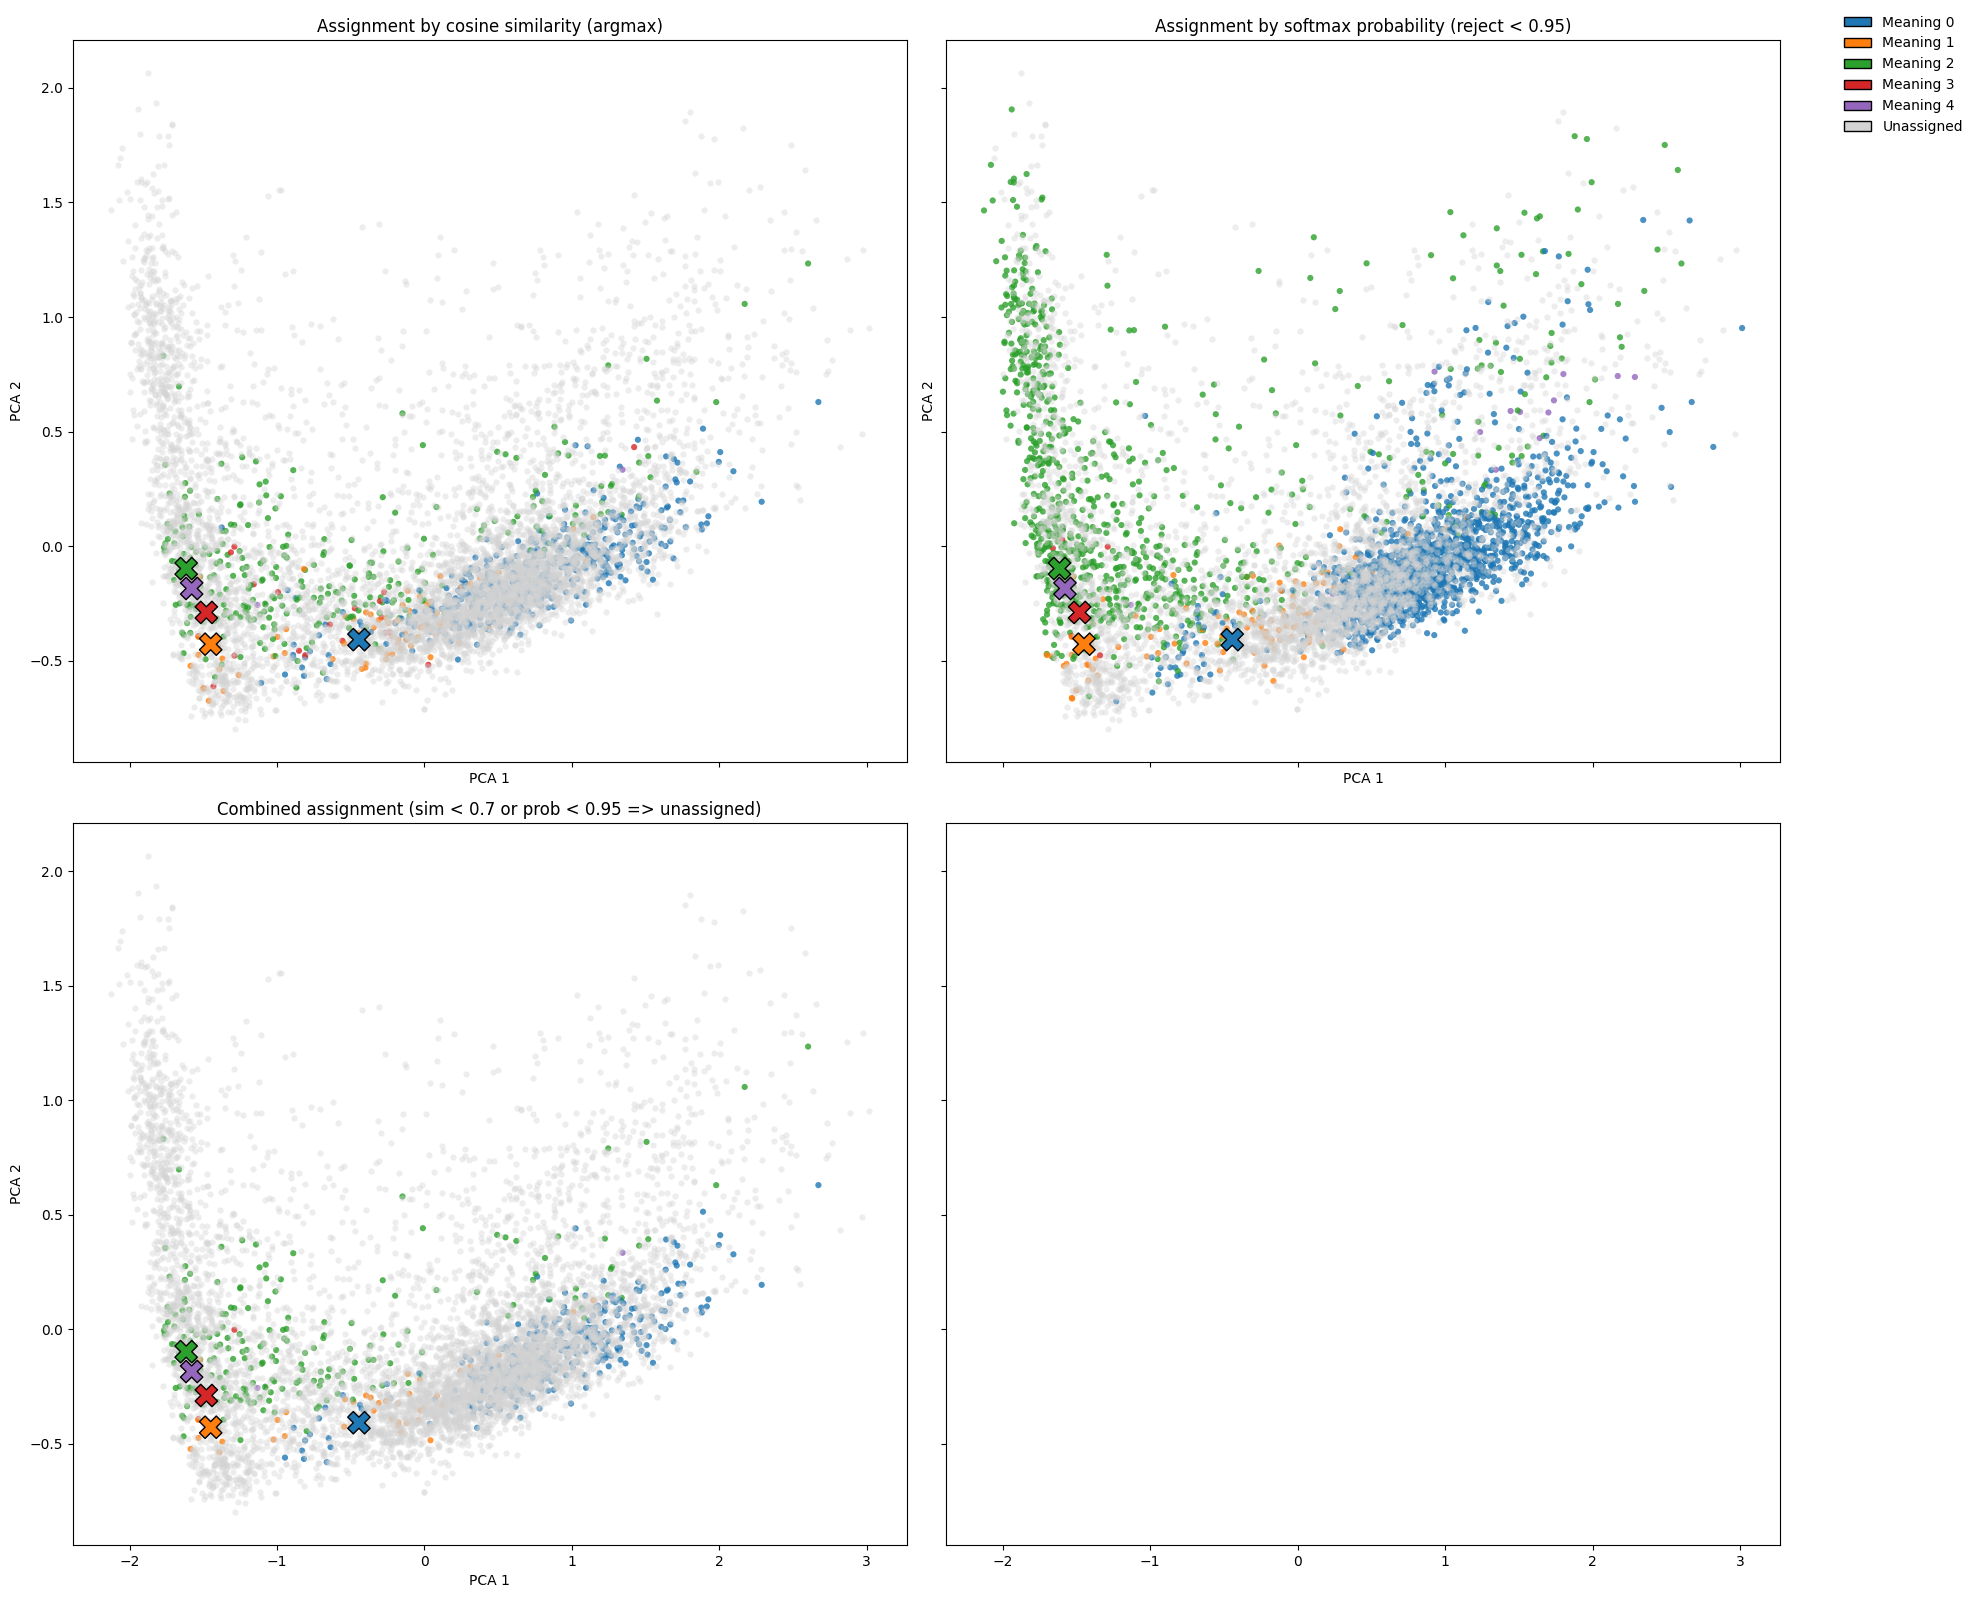

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16), sharex=True, sharey=True)

plot_assignment(
    axes[0, 0],
    "Assignment by cosine similarity (argmax)",
    assigned_sim,
    train_2d,
    meanings_2d,
)

plot_assignment(
    axes[0, 1],
    f"Assignment by softmax probability (reject < {CUT_OFF_PROBABILITY})",
    assigned_prob,
    train_2d,
    meanings_2d,
)

plot_assignment(
    axes[1, 0],
    f"Combined assignment (sim < {CUT_OFF_SIMILARITY} or prob < {CUT_OFF_PROBABILITY} => unassigned)",
    combined_classes,
    train_2d,
    meanings_2d,
)

# make [1, 1] empty
legend_handles = []

for i in range(n_meanings):
    name = f"Meaning {i}"
    if isinstance(meanings, (list, tuple)):
        g = meanings[i].get("gloss")
        if g:
            short = g[0] if isinstance(g, (list, tuple)) else g
            name = f"{i}: {short[:25]}{'...' if len(short) > 25 else ''}"

    legend_handles.append(
        Patch(facecolor=cmap(i), edgecolor="black", label=name)
    )

legend_handles.append(
    Patch(facecolor="lightgray", edgecolor="black", label="Unassigned")
)

fig.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

In [ ]:
# --------
# 4) Print top-k sentences per meaning (safe fallback if `meanings` contains human-readable glosses)
# --------
for meaning_idx in range(n_meanings):
    # indices of top-k train sentences (highest similarity to this meaning)
    top_indices = np.argsort(-prob_matrix[meaning_idx])
    
    # delete those, which have prob < CUT_OFF_PROBABILITY
    top_indices = [idx for idx in top_indices if prob_matrix[meaning_idx, idx] >= 0.95 and similarity_matrix[meaning_idx, idx] >= 0.64]

    # header
    header = f"Meaning {meaning_idx}"
    if isinstance(meanings, (list, tuple)) and meaning_idx < len(meanings):
        gloss = meanings[meaning_idx].get("gloss")
        if gloss:
            header += f": {gloss[0] if isinstance(gloss, (list, tuple)) else gloss}"
            
    print(header)
    
    for rank, sent_idx in enumerate(top_indices, start=1):
        sent = data[lemma_idx]["sentences"][sent_idx]
        sim = similarity_matrix[meaning_idx, sent_idx]
        prob = prob_matrix[meaning_idx, sent_idx]

        print(f"  {rank}. (idx={sent_idx}, sim={sim:.4f}, prob={prob:.4f}) {sent}")

    print()

Meaning 0
  1. (idx=4928, sim=0.7905, prob=0.9994) Коси на довге волосся - це красива і жіночна ідея.
  2. (idx=3110, sim=0.7703, prob=0.9992) "Я люблю мої довгі коси та сумуватиму, коли їх не стане.
  3. (idx=3978, sim=0.7539, prob=0.9991) А коси... коси у неї занадто пишні і довгі.
  4. (idx=481, sim=0.7769, prob=0.9988) Така ж довга густа коса, виразний погляд з-під чорних вій, струнка постава.
  5. (idx=2985, sim=0.8229, prob=0.9987) Свої довгі коси — коли і як за ними доглядати в таких умовах?
  6. (idx=1054, sim=0.8551, prob=0.9986) ЇЇ довге світле волосся, найчастіше заплетене у дві коси.
  7. (idx=3284, sim=0.7859, prob=0.9985) Її світле довге волосся заплетене в тугі коси.
  8. (idx=1830, sim=0.7357, prob=0.9985) У неї довге світле волосся, заплетене в коси.
  9. (idx=862, sim=0.7962, prob=0.9985) Бачиш, які на мені шати, яка довга коса?
  10. (idx=5598, sim=0.7984, prob=0.9984) Розкішне волосся кольору міді переплетене в коси,вільні пасма завиті в буклі по останній моді.
  11

## kmeans

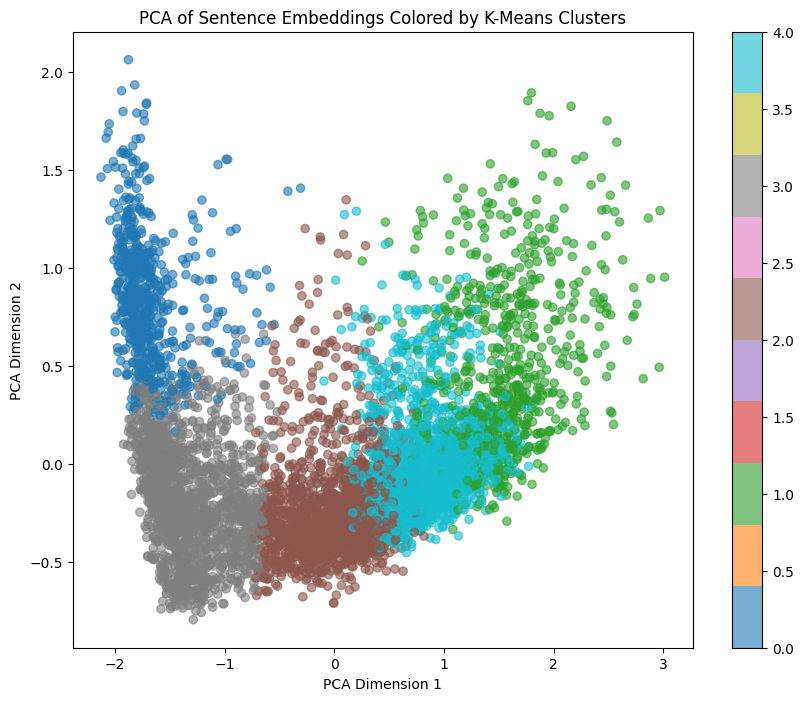

Cluster 1:
  - В Одеській області на Катранській косі, вздовж морського узбережжя. (Similarity to center: 0.9139)
  - Фото: Дмитро Смольєнко Косуля на території Обитічної коси, що на узбережжі Азовського моря. (Similarity to center: 0.9030)
  - Коса через Тилігульский лиман зі сторони села Прогресівка. (Similarity to center: 0.9008)
  - ЗСУ звільнили всю Миколаївщину, крім сіл на Кінбурнській косі (Similarity to center: 0.8961)
  - Війська рф знищують на півдні України унікальну заповідну Кінбурнську косу — омбудсменка (Similarity to center: 0.8941)

Cluster 2:
  - Звідти було видно Кінбурнська коса і вона з'являється на багатьох полотнах. (Similarity to center: 0.9716)
  - Отож можна говорити про те, що коса найшла на камінь всерйоз. (Similarity to center: 0.9656)
  - Невідома Кінбурнська коса Цього літа на повороті до села Стара Збур’ївка з’явилися інтригуючі дороговкази. (Similarity to center: 0.9630)
  - Остання та мабуть найекзотичніша локація — Кінбурнська коса. (Similarity to ce

In [ ]:
# make k-means clustering on train_set_embeddings with k = number of meanings
k = len(meanings)
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(train_set_embeddings)
labels = kmeans.labels_
labels.shape

# count how many sentences in each cluster
label_counts = Counter(labels)
label_counts

# plot PCA of train_set_embeddings colored by cluster labels
pca = PCA(n_components=2, random_state=42)
train_set_embeddings_2d = pca.fit_transform(train_set_embeddings)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    train_set_embeddings_2d[:, 0],
    train_set_embeddings_2d[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.6
)
plt.colorbar(scatter)
plt.title("PCA of Sentence Embeddings Colored by K-Means Clusters")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.show()

# print top 5 sentences from each cluster (that are closest to the cluster center)
for cluster_id in range(k):
    cluster_center = kmeans.cluster_centers_[cluster_id]
    cluster_sentences_indices = np.where(labels == cluster_id)[0]
    cluster_sentences_embeddings = train_set_embeddings[cluster_sentences_indices]
    similarities_to_center = cosine_similarity(cluster_sentences_embeddings, cluster_center.reshape(1, -1)).flatten()
    top_5_indices = np.argsort(-similarities_to_center)[:5]
    
    print(f"Cluster {cluster_id + 1}:")
    for idx in top_5_indices:
        sentence_idx = cluster_sentences_indices[idx]
        sentence = data[lemma_idx]["sentences"][sentence_idx]
        similarity_score = similarities_to_center[idx]
        print(f"  - {sentence} (Similarity to center: {similarity_score:.4f})")
    print()

In [ ]:
# спробувати  0.5 (лосс таргет ворд + сенсенсе)
# генерувати кластери на основі пробабіліті і взяти лише якщо п > 0.9